##### ARTI 560 - Computer Vision  
## Image Classification using Convolutional Neural Networks (CNNs) - Exercise 

### Objective

In this exercise, you will:

1. **Load the Fashion MNIST dataset** from the [Keras dataset](https://keras.io/api/datasets/) website.
2. **Preprocess the data** for training.
3. **Build your own CNN architecture** and evaluate the model.

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load Fashion MNIST data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Number of unique classes
num_classes = len(np.unique(y_train))
print(f"Number of unique classes: {num_classes}")

Number of unique classes: 10


In [3]:
# Define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

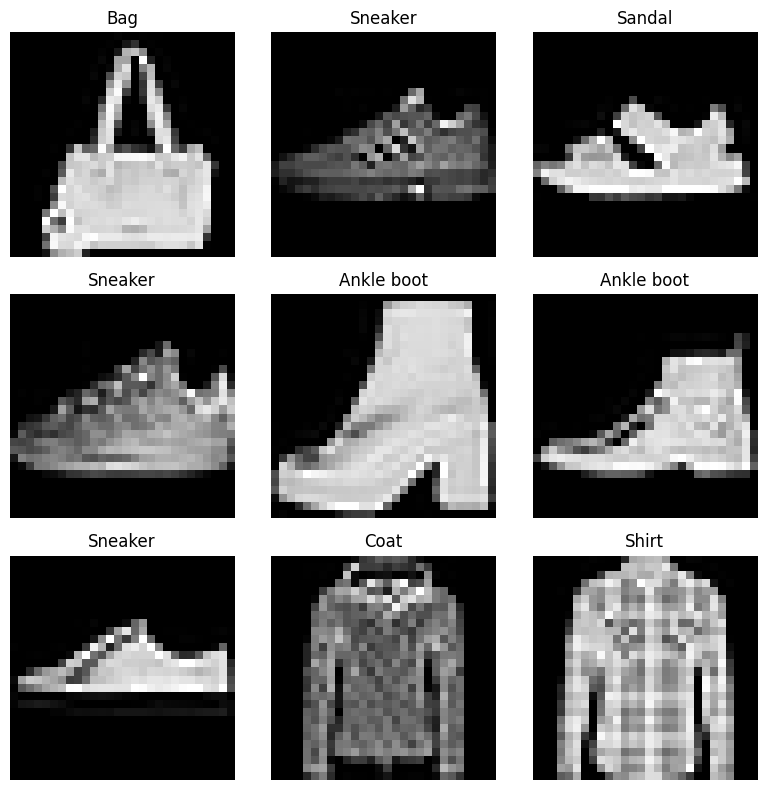

In [4]:
# Plot a 3x3 grid of random images from the dataset with their labels
plt.figure(figsize=(8, 8))
for i in range(9):
    idx = np.random.randint(0, len(x_train))
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

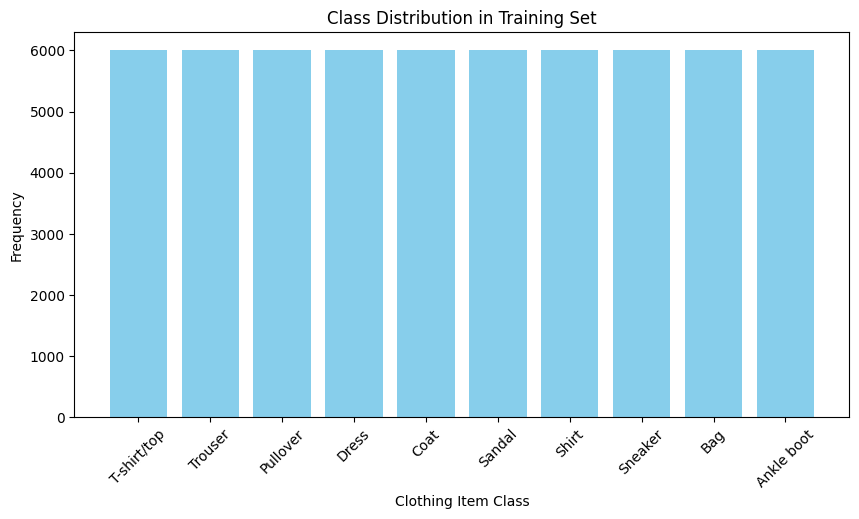

In [5]:
# Count occurrences of each class in the training set
unique_classes, counts = np.unique(y_train, return_counts=True)

# Plot the class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts, color='skyblue')
plt.title('Class Distribution in Training Set')
plt.xlabel('Clothing Item Class')
plt.ylabel('Frequency')
plt.xticks(rotation=45) 
plt.show()

### Build your Image Classification Model
Note: Don't use one hot encoding and use sparse_categorical_crossentropy for loss

In [6]:
# Import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Normalize pixel values for x_train and x_test (scaling them between 0 and 1)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_norm = np.expand_dims(x_train_norm, axis=-1)
x_test_norm = np.expand_dims(x_test_norm, axis=-1)

# One-hot encode the labels 

# Build a CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 output classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
print("Training the model...")
history = model.fit(x_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the model
print("\nEvaluating the model on test data...")
test_loss, test_acc = model.evaluate(x_test_norm, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Training the model...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.8141 - loss: 0.5182 - val_accuracy: 0.8669 - val_loss: 0.3767
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8785 - loss: 0.3345 - val_accuracy: 0.8756 - val_loss: 0.3318
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8954 - loss: 0.2852 - val_accuracy: 0.8952 - val_loss: 0.2911
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9066 - loss: 0.2566 - val_accuracy: 0.8942 - val_loss: 0.2853
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9153 - loss: 0.2313 - val_accuracy: 0.9075 - val_loss: 0.2555

Evaluating the model on test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9021 - loss: 0.2659

Final Test Accuracy: 0.9021
